In [1]:
## Imports

In [2]:
import scanpy as sc
import numpy as np
import scipy as sp
import os, sys

In [3]:
os.chdir('../../data')

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../..").resolve()))

In [ ]:
from src.markers import cell_cycle_markers, cell_type_markers

In [6]:
## Load data

In [7]:
g6_dz = sc.read_h5ad('egfDuod_G6_DZ.h5ad')

In [8]:
## Identify our normalised and raw matrices

In [9]:
g6_dz

AnnData object with n_obs × n_vars = 79448 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    uns: 'X_name'
    layers: 'counts'

In [10]:
print(g6_dz.layers["counts"][:50, :50].toarray())

[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 2.]
 ...
 [0. 0. 0. ... 1. 0. 1.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 2.]]


In [11]:
print(g6_dz.X[:50, :50].toarray())

[[0.         0.         0.         ... 0.         0.         0.95679329]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         1.84448057]
 ...
 [0.         0.         0.         ... 0.8663312  0.         0.8663312 ]
 [0.         0.         0.         ... 1.49278394 0.         0.        ]
 [0.         0.         0.         ... 0.         1.31981576 1.86956329]]


In [12]:
## Identify the highly variable genes from the raw data, using the 'binned' approach based on gene-expression

In [13]:
# adjusted to 3000 genes, for the purpose of the s_score

sc.pp.highly_variable_genes(g6_dz,flavor="seurat", n_top_genes=3000)

In [14]:
g6_dz

AnnData object with n_obs × n_vars = 79448 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg'
    layers: 'counts'

In [15]:

var = g6_dz[:, g6_dz.var['highly_variable']]

In [16]:
var

View of AnnData object with n_obs × n_vars = 79448 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg'
    layers: 'counts'

In [17]:
## Scale the variable genes, to account for different expression levels

In [18]:
sc.pp.scale(var, max_value=10)
sc.pp.scale(g6_dz, max_value=10)


/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [19]:
var


AnnData object with n_obs × n_vars = 79448 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    layers: 'counts'

In [20]:
print(np.min(var.X))
print(np.max(var.X))
print(np.std(var.X))

-8.439781281686138
10.0
0.5539672405455287


In [21]:
## Regress out the cell cycle effect, whilst preserving the original data for the trajectory analysis

In [22]:
s_genes  = [g for g in cell_cycle_markers["S_genes"]   if g in var.var_names]
s_genes

['POLA1', 'BRIP1']

In [23]:
g2m_genes = [g for g in cell_cycle_markers["G2M_genes"] if g in var.var_names]
g2m_genes

['HMGB2',
 'CDK1',
 'NUSAP1',
 'UBE2C',
 'TPX2',
 'TOP2A',
 'CKS2',
 'MKI67',
 'CENPF',
 'SMC4',
 'KIF20B',
 'CDC20',
 'DLGAP5',
 'HMMR',
 'ANLN',
 'CENPE',
 'GAS2L3']

In [24]:
sc.tl.score_genes_cell_cycle(var, s_genes=s_genes, g2m_genes=g2m_genes)

#var.obs['S_score'] = d2_dz.obs['S_score']
#var.obs['G2M_score'] = d2_dz.obs['G2M_score']

In [25]:
sc.pp.regress_out(var, ['S_score', 'G2M_score'])

In [26]:
## Dimensionality reduction

/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


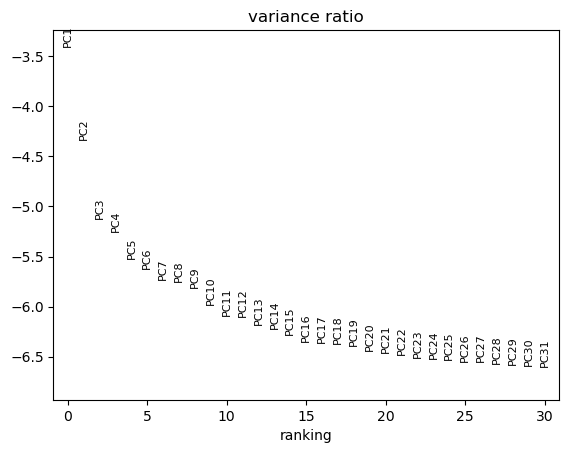

In [27]:
sc.tl.pca(var, n_comps=50, svd_solver="arpack", use_highly_variable=True)
sc.pl.pca_variance_ratio(var, log=True)

In [28]:
## Graph construction

sc.pp.neighbors(var, n_neighbors=100, n_pcs=30, use_rep='X', metric='euclidean')

python(2022) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
var.obsp.keys()


KeysView(PairwiseArrays with keys: distances, connectivities)

In [30]:
## Fine-grained clustering

In [31]:
sc.tl.leiden(var, resolution=3, n_iterations = -1)

/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_1740/739609301.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(var, resolution=3, n_iterations = -1)


In [32]:
var


AnnData object with n_obs × n_vars = 79448 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg', 'pca', 'neighbors', 'leiden'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

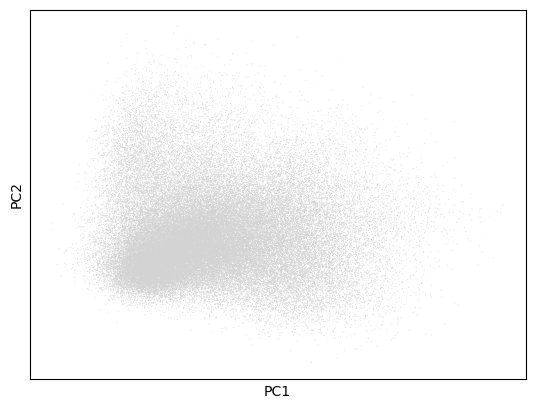

In [33]:
sc.pl.pca(var)

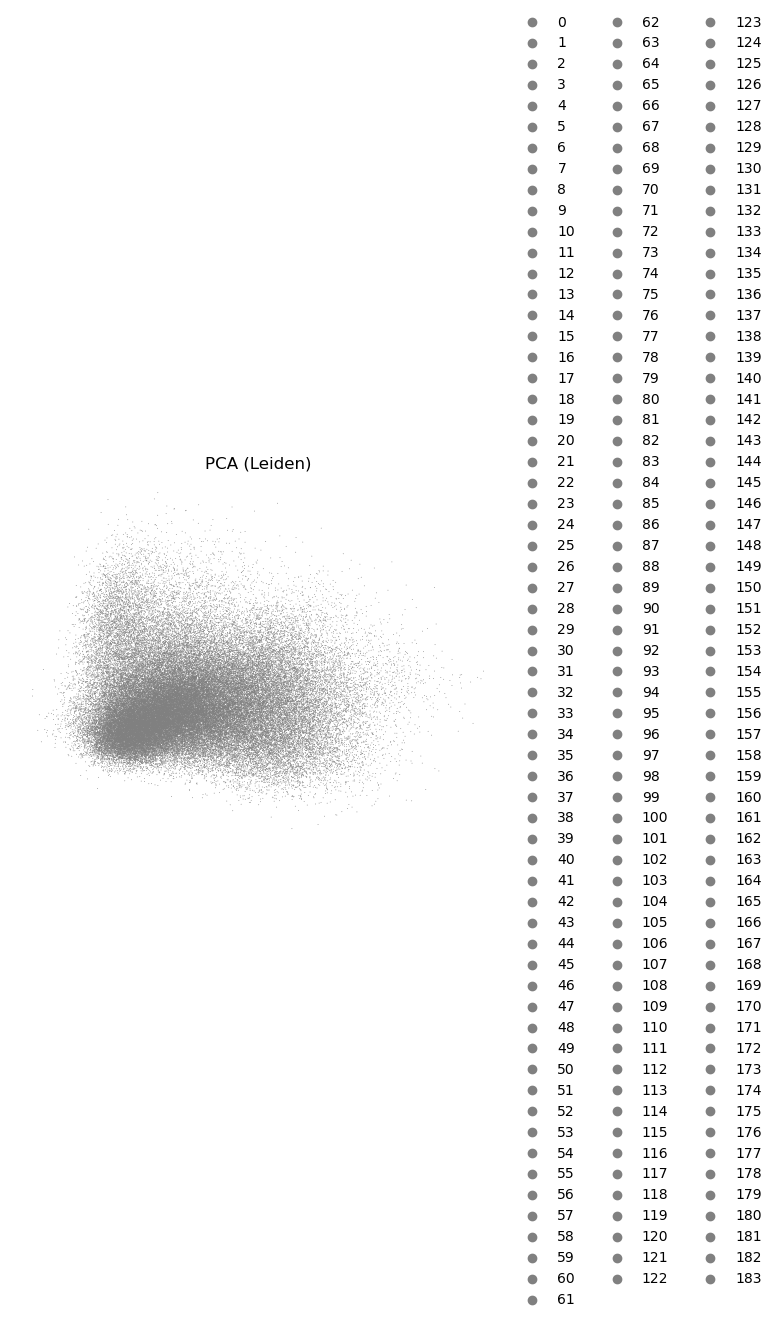

In [34]:
sc.pl.pca(
    var,
    color='leiden',  
    frameon=False,
    title='PCA (Leiden)'
)

In [35]:
## 134 clusters tells us we need to turn down the resolution for the leiden, or change the number of iterations

In [36]:
## let's try a lower resolution for this timepoint, from 1 to 0.8

sc.tl.leiden(var, resolution=1, n_iterations = 2)

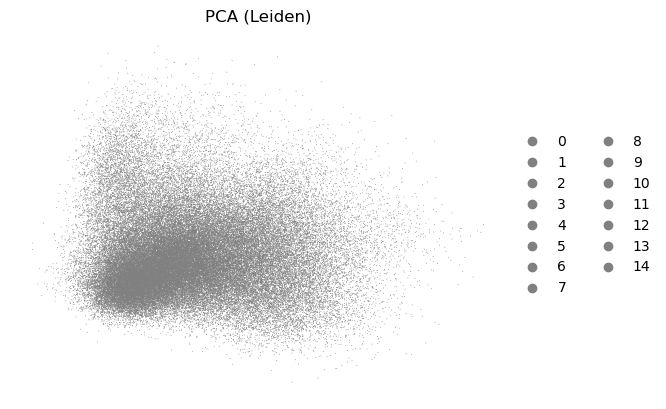

In [37]:
sc.pl.pca(
    var,
    color='leiden',  
    frameon=False,
    title='PCA (Leiden)'
)

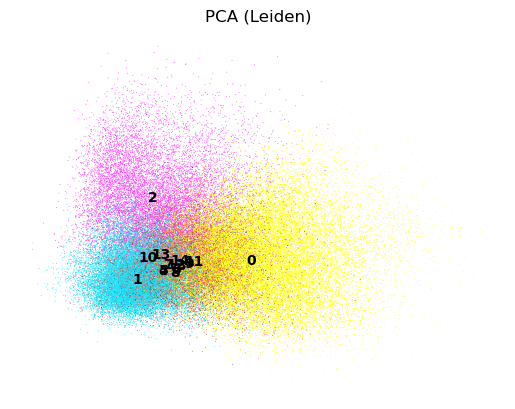

In [38]:
# 1) Ensure categorical
var.obs['leiden'] = var.obs['leiden'].astype('category')

# 2) Clear any cached colors for this key
if 'leiden_colors' in var.uns:
    del var.uns['leiden_colors']

# 3) Replot with an explicit palette
sc.pl.pca(
    var,
    color='leiden',
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    legend_loc='on data',
    frameon=False,
    title='PCA (Leiden)',
)


In [39]:
sc.tl.umap(var)

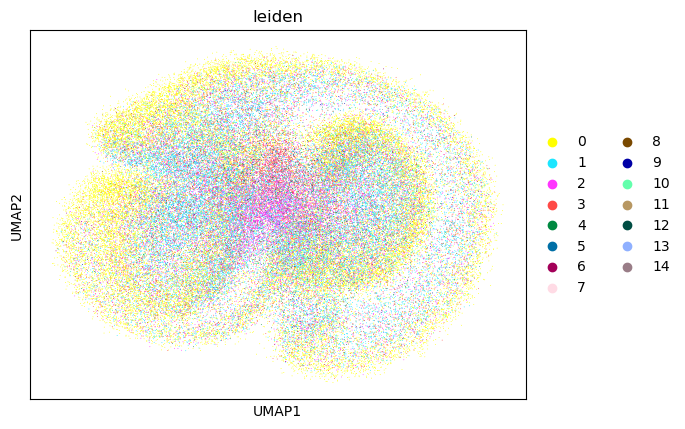

In [40]:
sc.pl.umap(var, color = 'leiden')

In [41]:
var

AnnData object with n_obs × n_vars = 79448 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg', 'pca', 'neighbors', 'leiden', 'leiden_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [42]:
## Add the metadata back to the original object

In [43]:
g6_dz.obsm['X_pca'] = var.obsm['X_pca']

In [44]:
g6_dz.obsm['X_umap'] = var.obsm['X_umap']

In [45]:
g6_dz

AnnData object with n_obs × n_vars = 79448 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [46]:
g6_dz.obs['leiden'] = var.obs['leiden'].astype('category')
g6_dz.obsp['distances'] = var.obsp['distances']
g6_dz.obsp['connectivities'] = var.obsp['connectivities']

In [47]:
g6_dz

AnnData object with n_obs × n_vars = 79448 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [48]:
var

AnnData object with n_obs × n_vars = 79448 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg', 'pca', 'neighbors', 'leiden', 'leiden_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [49]:
## Save our clustered data

intermediate_directory = '/Users/stanleydale/user_generated/breault-lab/single-cell/analysis'
sc.write(f'{intermediate_directory}/clustered_egfDuod_G6_DZ.h5ad', g6_dz)